# MLP Hyperparameter Tuning on `micro_mobility_training_data_2025.csv`

Time-aware tuning for MLP using a chronological validation window (no random CV).


## Colab Setup

- Auto-detect Colab and mount Google Drive.
- Update `COLAB_PROJECT_ROOT` if your Drive path is different.


## Step 1: Environment and Libraries

Loads required libraries for preprocessing, tuning, modeling, and evaluation.


In [1]:
from pathlib import Path
import json
import time
import itertools
import numpy as np
import pandas as pd

from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterSampler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## Step 2: Paths and Runtime Config

Defines dataset/artifact paths and tuning budgets (`N_TRIALS`, `VAL_DAYS`, `HOLDOUT_DAYS`).


In [2]:
# Paths and config
COLAB_PROJECT_ROOT = Path('/content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction')

IN_COLAB = False
try:
    import google.colab  # type: ignore
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT = COLAB_PROJECT_ROOT
else:
    PROJECT_ROOT = Path.cwd().resolve().parents[1]

DATA_PATH = PROJECT_ROOT / 'data' / 'proceed' / 'micro_mobility_training_data_2025.csv'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'model_training' / 'mlp' / 'tuned_v1'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

HOLDOUT_DAYS = 7
VAL_DAYS = 14
RANDOM_STATE = 42
N_TRIALS = 12

print('IN_COLAB:', IN_COLAB)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_PATH:', DATA_PATH)
print('ARTIFACT_DIR:', ARTIFACT_DIR)

NOTEBOOK_T0 = time.perf_counter()


Mounted at /content/drive
IN_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction
DATA_PATH: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/data/proceed/micro_mobility_training_data_2025.csv
ARTIFACT_DIR: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/mlp/tuned_v1


## Step 3: Data Load and Chronological Split

Builds train/validation/test splits by date (no random split) to avoid leakage.


In [3]:
data_prep_t0 = time.perf_counter()
# Load data and build split
cols = [
    'station', 'date', 'hour', 'net_demand',
    'lat', 'lng', 'hour_sin', 'hour_cos', 'day_of_week', 'day_sin', 'day_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h'
]

df = pd.read_csv(DATA_PATH, usecols=cols)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date', 'station', 'net_demand']).copy()

stations_sorted = sorted(df['station'].dropna().unique().tolist())
station_to_id = {s: i for i, s in enumerate(stations_sorted)}
df['station_id'] = df['station'].map(station_to_id).astype('int32')

feature_cols = [
    'station_id', 'hour', 'lat', 'lng', 'hour_sin', 'hour_cos',
    'day_of_week', 'day_sin', 'day_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h'
]

max_date = df['date'].max().normalize()
test_cutoff = max_date - pd.Timedelta(days=HOLDOUT_DAYS)
val_cutoff = test_cutoff - pd.Timedelta(days=VAL_DAYS)

train_mask = df['date'] <= val_cutoff
val_mask = (df['date'] > val_cutoff) & (df['date'] <= test_cutoff)
test_mask = df['date'] > test_cutoff

X_train = df.loc[train_mask, feature_cols].astype('float32')
y_train = df.loc[train_mask, 'net_demand'].astype('float32')
X_val = df.loc[val_mask, feature_cols].astype('float32')
y_val = df.loc[val_mask, 'net_demand'].astype('float32')
X_test = df.loc[test_mask, feature_cols].astype('float32')
y_test = df.loc[test_mask, 'net_demand'].astype('float32')

print('Rows total:', len(df))
print('Train rows:', len(X_train))
print('Val rows:', len(X_val))
print('Test rows:', len(X_test))
print('Val cutoff:', val_cutoff.date())
print('Test cutoff:', test_cutoff.date())

data_prep_seconds = float(time.perf_counter() - data_prep_t0)
print(f'Data prep time: {data_prep_seconds:.2f} sec ({data_prep_seconds/60:.2f} min)')


Rows total: 4266120
Train rows: 4020672
Val rows: 163632
Test rows: 81816
Val cutoff: 2025-12-10
Test cutoff: 2025-12-24
Data prep time: 16.22 sec (0.27 min)


## Step 4: Hyperparameter Search Space

Defines candidate values for MLP architecture and optimization settings.


In [ ]:
# Randomized search space
param_dist = {
    'hidden_layer_sizes': [(128,64), (256,128), (256,128,64), (128,128)],
    'alpha': [1e-5, 1e-4, 5e-4, 1e-3],
    'learning_rate_init': [5e-4, 1e-3, 2e-3],
    'batch_size': [1024, 2048, 4096],
    'max_iter': [35, 50],
}

trials = list(ParameterSampler(param_dist, n_iter=N_TRIALS, random_state=RANDOM_STATE))
print('Trials:', len(trials))


Trials: 12


## Step 5: Tuning Loop

Runs randomized trials and tracks per-trial validation metrics + runtime.


In [ ]:
# Tune on train/val
trial_rows = []
best = None
tuning_t0 = time.perf_counter()

for idx, p in enumerate(trials, start=1):
    t0 = time.perf_counter()
    base_mlp = MLPRegressor(
        hidden_layer_sizes=p['hidden_layer_sizes'],
        activation='relu',
        solver='adam',
        alpha=p['alpha'],
        batch_size=p['batch_size'],
        learning_rate='adaptive',
        learning_rate_init=p['learning_rate_init'],
        max_iter=p['max_iter'],
        early_stopping=True,
        validation_fraction=0.05,
        n_iter_no_change=5,
        random_state=RANDOM_STATE,
        verbose=False,
    )

    model = TransformedTargetRegressor(
        regressor=Pipeline([
            ('x_scaler', StandardScaler(with_mean=True, with_std=True)),
            ('mlp', base_mlp),
        ]),
        transformer=StandardScaler(with_mean=True, with_std=True)
    )

    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_mae = float(mean_absolute_error(y_val, val_pred))
    val_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
    elapsed = float(time.perf_counter() - t0)

    row = {
        'trial': idx,
        **{k: str(v) for k,v in p.items()},
        'val_mae': val_mae,
        'val_rmse': val_rmse,
        'train_seconds': elapsed,
    }
    trial_rows.append(row)

    if best is None or val_mae < best['val_mae']:
        best = {'params': p, 'val_mae': val_mae, 'val_rmse': val_rmse}

    print(f"[{idx}/{len(trials)}] val_mae={val_mae:.4f} val_rmse={val_rmse:.4f} time={elapsed:.1f}s params={p}")

trials_df = pd.DataFrame(trial_rows).sort_values('val_mae')
print('Best by val MAE:')
print(trials_df.head(3))

tuning_seconds = float(time.perf_counter() - tuning_t0)
print(f'Tuning loop time: {tuning_seconds:.2f} sec ({tuning_seconds/60:.2f} min)')


[1/12] val_mae=0.5196 val_rmse=0.8455 time=423.5s params={'max_iter': 50, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 128), 'batch_size': 2048, 'alpha': 1e-05}
[2/12] val_mae=0.2291 val_rmse=0.3872 time=1057.5s params={'max_iter': 50, 'learning_rate_init': 0.0005, 'hidden_layer_sizes': (256, 128, 64), 'batch_size': 1024, 'alpha': 0.0005}
[3/12] val_mae=0.2260 val_rmse=0.4401 time=780.2s params={'max_iter': 35, 'learning_rate_init': 0.002, 'hidden_layer_sizes': (256, 128, 64), 'batch_size': 2048, 'alpha': 0.001}
[4/12] val_mae=0.5195 val_rmse=0.8347 time=411.5s params={'max_iter': 35, 'learning_rate_init': 0.0005, 'hidden_layer_sizes': (128, 128), 'batch_size': 2048, 'alpha': 1e-05}
[5/12] val_mae=0.4805 val_rmse=0.7637 time=710.9s params={'max_iter': 50, 'learning_rate_init': 0.0005, 'hidden_layer_sizes': (256, 128, 64), 'batch_size': 2048, 'alpha': 0.0005}
[6/12] val_mae=0.2548 val_rmse=0.4500 time=626.5s params={'max_iter': 50, 'learning_rate_init': 0.001, 'hidden_layer_

## Load best model from stored artifacts.

In [4]:
# Load best hyperparameters from artifact (skip tuning rerun)
# Skip when data split/features/model definition are changed.
import json
import ast
import pandas as pd

metrics_path = ARTIFACT_DIR / "metrics.json"
trials_path = ARTIFACT_DIR / "trials.csv"

with open(metrics_path, "r", encoding="utf-8") as f:
    m = json.load(f)

trials_df = pd.read_csv(trials_path)

bp = m["best_params"]
if isinstance(bp.get("hidden_layer_sizes"), list):
    bp["hidden_layer_sizes"] = tuple(bp["hidden_layer_sizes"])

best = {
    "params": bp,
    "val_mae": float(m.get("best_val_mae", float("nan"))),
    "val_rmse": float(m.get("best_val_rmse", float("nan"))),
}

print("Loaded best params:", bp)
print("best_val_mae:", best["val_mae"], "best_val_rmse:", best["val_rmse"])


Loaded best params: {'max_iter': 50, 'learning_rate_init': 0.002, 'hidden_layer_sizes': (128, 64), 'batch_size': 1024, 'alpha': 0.0001}
best_val_mae: 0.14074760675430298 best_val_rmse: 0.2840262323146787


## Step 6: Final Refit and Test Evaluation

Retrains with best hyperparameters on train+val, then evaluates on holdout test.


In [5]:
# Refit best model on train+val, then predict on train/test
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)
import numpy as np
import pandas as pd
import time

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

bp = best["params"]

base_mlp = MLPRegressor(
    hidden_layer_sizes=bp["hidden_layer_sizes"],
    activation="relu",
    solver="adam",
    alpha=bp["alpha"],
    batch_size=bp["batch_size"],
    learning_rate="adaptive",
    learning_rate_init=bp["learning_rate_init"],
    max_iter=bp["max_iter"],
    early_stopping=True,
    validation_fraction=0.05,
    n_iter_no_change=5,
    random_state=RANDOM_STATE,
    verbose=False,
)

best_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("x_scaler", StandardScaler(with_mean=True, with_std=True)),
        ("mlp", base_mlp),
    ]),
    transformer=StandardScaler(with_mean=True, with_std=True),
)

t0 = time.perf_counter()
best_model.fit(X_train_full, y_train_full)
final_train_seconds = float(time.perf_counter() - t0)

train_pred = best_model.predict(X_train_full)
test_pred = best_model.predict(X_test)

print(f"Final fit time: {final_train_seconds:.2f} sec ({final_train_seconds/60:.2f} min)")


Final fit time: 114.39 sec (1.91 min)


In [6]:
# Full report metrics (train + test)
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom))

train_mae = float(mean_absolute_error(y_train_full, train_pred))
train_rmse = float(np.sqrt(mean_squared_error(y_train_full, train_pred)))
train_r2 = float(r2_score(y_train_full, train_pred))
train_mape = float(mean_absolute_percentage_error(y_train_full, train_pred))
train_smape = smape(y_train_full, train_pred)

test_mae = float(mean_absolute_error(y_test, test_pred))
test_rmse = float(np.sqrt(mean_squared_error(y_test, test_pred)))
test_r2 = float(r2_score(y_test, test_pred))
test_mape = float(mean_absolute_percentage_error(y_test, test_pred))
test_smape = smape(y_test, test_pred)

summary_df = pd.DataFrame([
    {"split":"train_full", "MAE":train_mae, "RMSE":train_rmse, "R2":train_r2, "MAPE":train_mape, "sMAPE":train_smape},
    {"split":"test",       "MAE":test_mae,  "RMSE":test_rmse,  "R2":test_r2,  "MAPE":test_mape,  "sMAPE":test_smape},
])

display(summary_df)


,split,MAE,RMSE,R2,MAPE,sMAPE
0,train_full,0.154398,0.298358,0.999997,2.344275e+14,1.416285
1,test,0.154399,0.298366,0.999997,2.344170e+14,1.416285


In [7]:
# Hourly and station-level error analysis for report
# needs original df rows aligned with test set:
test_rows = df.loc[test_mask, ["station", "date", "hour"]].reset_index(drop=True)
eval_test = pd.DataFrame({
    "station": test_rows["station"],
    "date": test_rows["date"],
    "hour": test_rows["hour"].astype(int),
    "y_true": y_test.reset_index(drop=True),
    "y_pred": pd.Series(test_pred),
})
eval_test["abs_err"] = (eval_test["y_true"] - eval_test["y_pred"]).abs()

hourly_mae = eval_test.groupby("hour", as_index=False)["abs_err"].mean().rename(columns={"abs_err":"mae"})
station_mae = eval_test.groupby("station", as_index=False)["abs_err"].mean().rename(columns={"abs_err":"mae"})
station_mae = station_mae.sort_values("mae", ascending=False)

print("Top 10 worst stations by MAE:")
display(station_mae.head(10))

print("Top 10 best stations by MAE:")
display(station_mae.tail(10).sort_values("mae", ascending=True))

display(hourly_mae)


Top 10 worst stations by MAE:


,station,mae
232,Grove St PATH,0.934557
461,Warren St,0.707878
279,Madison St & 1 St,0.704116
347,River St & Newark St,0.682997
242,Hoboken Terminal - River St & Hudson Pl,0.671116
482,Willow Ave & 12 St,0.645644
287,Marin Light Rail,0.638207
73,Bergen Ave & Sip Ave,0.612115
206,Essex Light Rail,0.605851
13,2 St & Park Ave,0.596745


Top 10 best stations by MAE:


,station,mae
423,W 41 St & 8 Ave,0.040824
438,W 51 St & 7 Ave,0.042814
409,W 27 St & 7 Ave,0.042869
437,W 51 St & 6 Ave,0.044415
405,W 24 St & 7 Ave,0.044421
412,W 30 St & 8 Ave,0.045145
277,MacDougal St & Washington Sq,0.046138
425,W 42 St & 8 Ave,0.046231
393,W 17 St & 7 Ave,0.046368
420,W 37 St & Broadway,0.046832


,hour,mae
0,0,0.145050
1,1,0.119654
2,2,0.103991
3,3,0.108836
4,4,0.112625
5,5,0.111114
6,6,0.129975
7,7,0.150882
8,8,0.167960
9,9,0.214657


## Step 7: Save Artifacts

Writes trial table, model, and metrics JSON for reporting/reproducibility.


In [8]:
# Save report-ready artifacts
import joblib
import json
from pathlib import Path

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# model
joblib.dump(best_model, ARTIFACT_DIR / "mlp_model_tuned.joblib")

# tables
trials_df.to_csv(ARTIFACT_DIR / "trials.csv", index=False)
summary_df.to_csv(ARTIFACT_DIR / "report_summary_metrics.csv", index=False)
hourly_mae.to_csv(ARTIFACT_DIR / "hourly_mae_test.csv", index=False)
station_mae.to_csv(ARTIFACT_DIR / "station_mae_test.csv", index=False)
eval_test.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)

# json metrics
total_notebook_seconds = float(time.perf_counter() - NOTEBOOK_T0)
metrics = {
    "model": "MLPRegressor_tuned",
    "data_path": str(DATA_PATH),
    "holdout_days": HOLDOUT_DAYS,
    "val_days": VAL_DAYS,
    "n_trials": int(len(trials_df)),
    "best_params": {k: (list(v) if isinstance(v, tuple) else v) for k, v in bp.items()},
    "best_val_mae": float(best["val_mae"]),
    "best_val_rmse": float(best["val_rmse"]),
    "train_full": {
        "mae": train_mae, "rmse": train_rmse, "r2": train_r2, "mape": train_mape, "smape": train_smape
    },
    "test": {
        "mae": test_mae, "rmse": test_rmse, "r2": test_r2, "mape": test_mape, "smape": test_smape
    },
    "timing": {
        "final_train_seconds": final_train_seconds,
        "total_notebook_seconds": total_notebook_seconds
    }
}
with open(ARTIFACT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved report artifacts to:", ARTIFACT_DIR)


Saved report artifacts to: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/mlp/tuned_v1


### Plot the diagrams using stored artifacts.

In [9]:
# Cell 1: Imports + artifact paths
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Update this if needed
# ARTIFACT_DIR = Path("artifacts/model_training/mlp/tuned_v1")
# print("ARTIFACT_DIR:", ARTIFACT_DIR.resolve())

metrics_path = ARTIFACT_DIR / "metrics.json"
trials_path = ARTIFACT_DIR / "trials.csv"
pred_path = ARTIFACT_DIR / "test_predictions.csv"
hourly_path = ARTIFACT_DIR / "hourly_mae_test.csv"
station_path = ARTIFACT_DIR / "station_mae_test.csv"

for p in [metrics_path, trials_path, pred_path, hourly_path, station_path]:
    print(p.name, "exists:", p.exists())


metrics.json exists: True
trials.csv exists: True
test_predictions.csv exists: True
hourly_mae_test.csv exists: True
station_mae_test.csv exists: True


In [10]:
# Cell 2: Load artifacts
metrics = {}
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

trials_df = pd.read_csv(trials_path) if trials_path.exists() else None
pred_df = pd.read_csv(pred_path) if pred_path.exists() else None
hourly_df = pd.read_csv(hourly_path) if hourly_path.exists() else None
station_df = pd.read_csv(station_path) if station_path.exists() else None

print("Loaded:")
print("trials_df:", None if trials_df is None else trials_df.shape)
print("pred_df  :", None if pred_df is None else pred_df.shape)
print("hourly_df:", None if hourly_df is None else hourly_df.shape)
print("station_df:", None if station_df is None else station_df.shape)

if metrics:
    print("\nMetrics summary keys:", list(metrics.keys()))


Loaded:
trials_df: (12, 9)
pred_df  : (81816, 6)
hourly_df: (24, 2)
station_df: (487, 2)

Metrics summary keys: ['model', 'data_path', 'holdout_days', 'val_days', 'n_trials', 'best_params', 'best_val_mae', 'best_val_rmse', 'train_full', 'test', 'timing']


In [13]:
# Load model and predict
import joblib
import numpy as np
from pathlib import Path

model_path = ARTIFACT_DIR / 'mlp_model_tuned.joblib'
loaded_model = joblib.load(model_path)

# X_new must have same feature columns/order used in training
# e.g. feature_cols = ['station_id','hour','lat','lng','hour_sin','hour_cos','day_of_week','day_sin','day_cos','lag_1h','lag_2h','lag_3h','lag_24h','rolling_mean_3h']
# y_pred = loaded_model.predict(X_train)

# print("Predictions shape:", np.asarray(y_pred).shape)


In [14]:
# Cell 1: Prepare predictions + metrics (needed by all plots)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# If not already predicted
train_pred = loaded_model.predict(X_train_full)
test_pred = loaded_model.predict(X_test)

train_rmse = float(np.sqrt(mean_squared_error(y_train_full, train_pred)))
train_mae  = float(mean_absolute_error(y_train_full, train_pred))
test_rmse  = float(np.sqrt(mean_squared_error(y_test, test_pred)))
test_mae   = float(mean_absolute_error(y_test, test_pred))

print(f"Train RMSE={train_rmse:.4f}, Train MAE={train_mae:.4f}")
print(f"Test  RMSE={test_rmse:.4f}, Test  MAE={test_mae:.4f}")

# Build test eval frame with datetime
test_rows = df.loc[test_mask, ["date", "hour", "station"]].reset_index(drop=True)
test_eval = pd.DataFrame({
    "date": pd.to_datetime(test_rows["date"]),
    "hour": test_rows["hour"].astype(int),
    "station": test_rows["station"],
    "actual": np.asarray(y_test),
    "pred": np.asarray(test_pred),
})
test_eval["datetime_hour"] = test_eval["date"] + pd.to_timedelta(test_eval["hour"], unit="h")


Train RMSE=0.2984, Train MAE=0.1544
Test  RMSE=0.2984, Test  MAE=0.1544


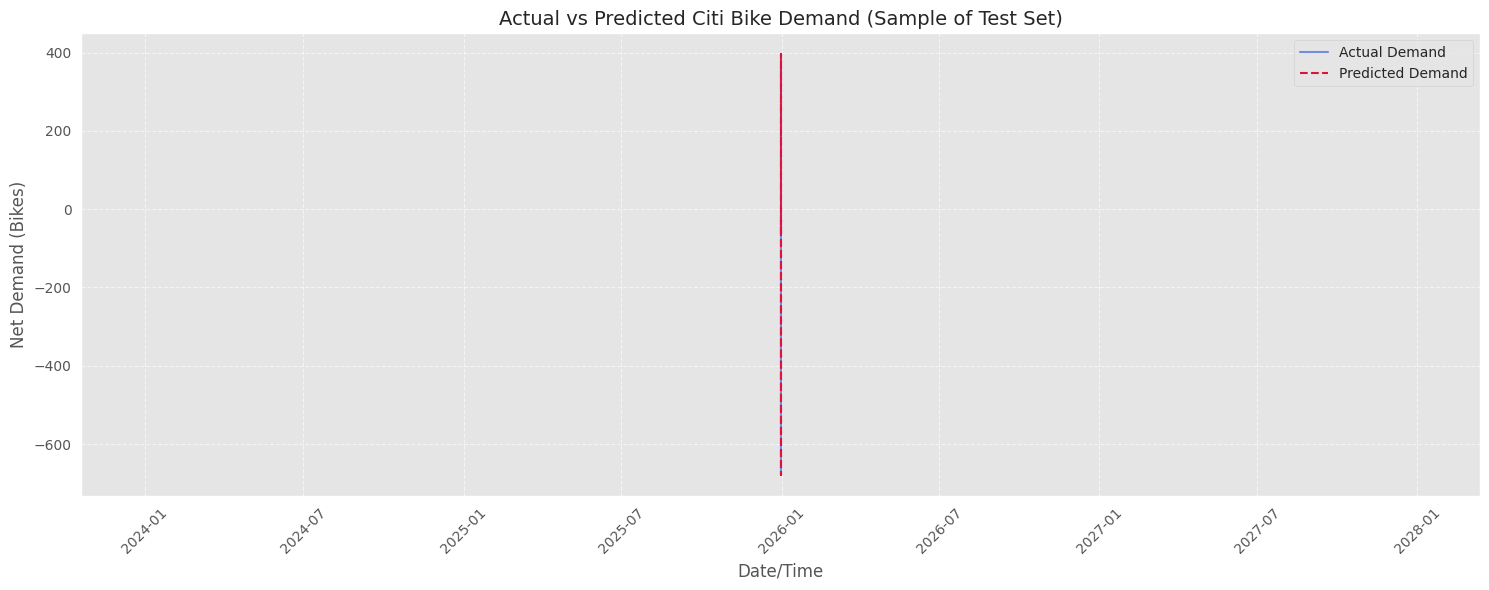

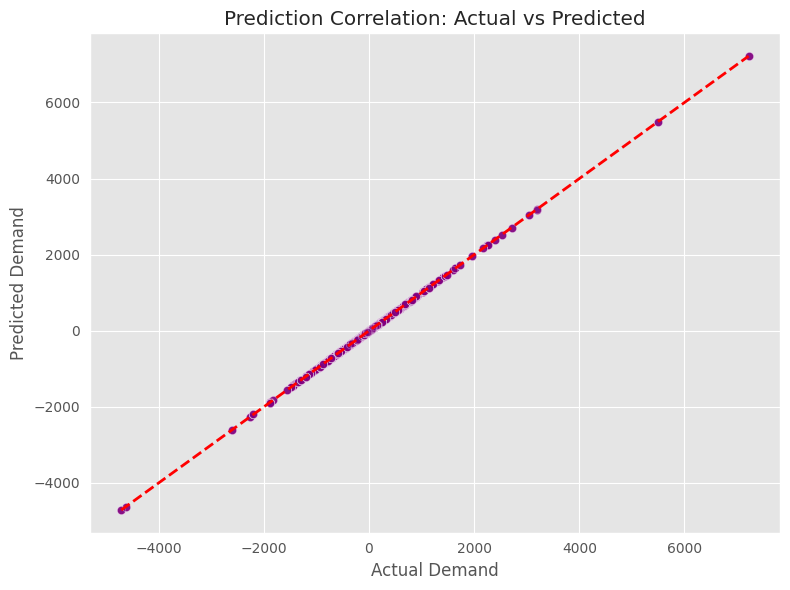

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

# 1. Load the final model from the checkpoint
# print("Loading model for visualization...")
# final_model = joblib.load(checkpoint_path)

# 2. Generate predictions
# We use the X_test created in your previous cells
# y_preds = final_model.predict(X_test)

# 3. Create a DataFrame for plotting
results_df = pd.DataFrame({
    'Date': df.loc[test_mask, 'date'],
    'Actual': y_test.values,
    'Predicted': test_pred
}).sort_values('Date')

# 4. Plotting
plt.figure(figsize=(15, 6))

# Let's plot a subset (e.g., the last 500 observations) for better visibility
# If you want the whole test set, remove the .tail(500)
plot_data = results_df.tail(500)

plt.plot(plot_data['Date'], plot_data['Actual'],
         label="Actual Demand", color="royalblue", alpha=0.7)

plt.plot(plot_data['Date'], plot_data['Predicted'],
         label="Predicted Demand", color="crimson", linestyle='--')

plt.title('Actual vs Predicted Citi Bike Demand (Sample of Test Set)', fontsize=14)
plt.xlabel('Date/Time', fontsize=12)
plt.ylabel('Net Demand (Bikes)', fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Scatter Plot for Correlation
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=test_pred, alpha=0.3, color='purple')

# 45-degree reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.title('Prediction Correlation: Actual vs Predicted')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')

plt.tight_layout()
plt.show()

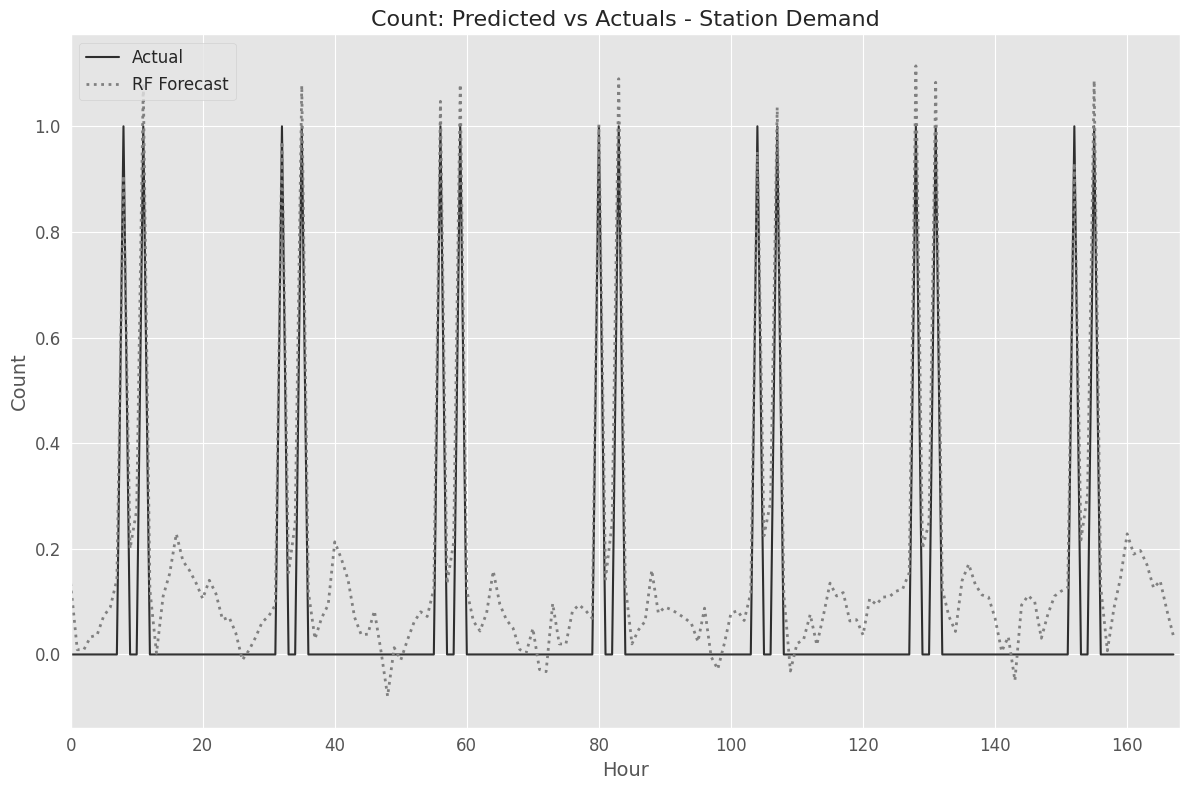

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import joblib

# 1. Load your model and get predictions
# final_model = joblib.load(checkpoint_path)
# y_preds_rf = final_model.predict(X_test)

# 2. Prepare the data
# We sample a window of time to match the ~175 hour window in your image
# Assuming your X_test is sorted chronologically
plot_window = 168  # one week of hourly data

y_actual_slice = y_test.values[:plot_window]
y_rf_slice = train_pred[:plot_window]
hours = np.arange(len(y_actual_slice))

# 3. Plotting with the specific styling from your image
plt.figure(figsize=(12, 8))

# Actual Demand - Solid thick line
plt.plot(hours, y_actual_slice,
         label='Actual',
         color='black',
         linewidth=1.5,
         alpha=0.8)

# RF Forecast - Dotted line (matching the image)
plt.plot(hours, y_rf_slice,
         label='RF Forecast',
         color='gray',
         linestyle=':',
         linewidth=2)

# Styling to match the uploaded image
plt.title('Count: Predicted vs Actuals - Station Demand', fontsize=16)
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(loc='upper left', frameon=True, fontsize=12)

# Adjust ticks and grid
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0, plot_window)

plt.tight_layout()
plt.show()

Generating predictions...

PERFORMANCE COMPARISON
Training RMSE: 0.2993
Testing RMSE:  0.2984
------------------------------
Training MAE:  0.1548
Testing MAE:   0.1544


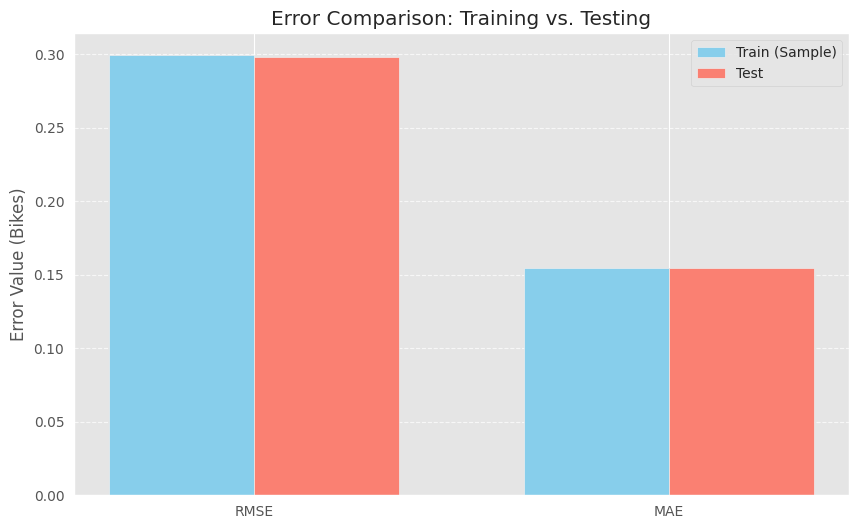

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

# 1. Load the final trained model
# print("Loading model...")
# final_model = joblib.load(checkpoint_path)

# 2. Sample the training data for faster evaluation
# Calculating errors on 4M+ rows can be slow; 100k-500k is usually enough for a diagnostic
train_sample_size = 500000

X_train_sample = X_train.sample(n=train_sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# 3. Generate Predictions
print("Generating predictions...")
train_preds = loaded_model.predict(X_train_sample)
test_preds = loaded_model.predict(X_test)

# 4. Calculate Metrics
train_rmse = np.sqrt(mean_squared_error(y_train_sample, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_mae = mean_absolute_error(y_train_sample, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)

# 5. Print Comparison
print("\n" + "=" * 30)
print("PERFORMANCE COMPARISON")
print("=" * 30)
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE:  {test_rmse:.4f}")
print("-" * 30)
print(f"Training MAE:  {train_mae:.4f}")
print(f"Testing MAE:   {test_mae:.4f}")
print("=" * 30)

# 6. Visualize the Gap
labels = ['RMSE', 'MAE']
train_metrics = [train_rmse, train_mae]
test_metrics = [test_rmse, test_mae]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_metrics, width, label='Train (Sample)', color='skyblue')
rects2 = ax.bar(x + width/2, test_metrics, width, label='Test', color='salmon')

ax.set_ylabel('Error Value (Bikes)')
ax.set_title('Error Comparison: Training vs. Testing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()